## Test mask exploration #2

In [1]:
# assure le reload de src si modifications sont faite

%load_ext autoreload
%autoreload 2

In [2]:
# import utilitaires

%matplotlib inline

import librosa as rosa
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp

from IPython.display import Audio
from pathlib import Path

In [3]:
# import package develope pour le projet

import ffury

from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)
from ffury.transforms import spectrogram_from_audio
from ffury.eda import show_transforms, show_distributions


def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
# charger data entrainement non indexe

train_csv_filename = config.get_csv_filename(DatasetType.TRAIN)
train_data_df = pd.read_csv(train_csv_filename)
train_audio_filenames = train_data_df["filename"].unique()

In [8]:
# fonctions utilitaires

def waveform_show(waveform, sr, start_s=0):
    ticks = range(0, len(waveform) + 1, int(sr * 0.5))
    plt.plot(waveform)
    plt.xlim(ticks[0], ticks[-1])
    plt.xticks(ticks,
              [round(start_s + t / sr, 2) for t in ticks])

def waveform_load(path, start_ms=None, stop_ms=None):
    # loading + features
    filename = Path.joinpath(config.paths.DATA_DIR, "audio", f"{path}.ogg")
    print(filename)

    waveform, sr = rosa.load(filename,
                             sr=config.preprocess.clip_sampling_rate_hz)

    if start_ms is None:
        start_ms = 0

    if stop_ms is None:
        stop_ms = len(waveform) * sr * 1000

    start_s = start_ms / 1000
    stop_s = stop_ms / 1000
    wave_start = int(start_s * sr)
    wave_stop = int(stop_s * sr)
    return waveform[wave_start:wave_stop], sr

def spectrogram_load(path, start_ms=None, stop_ms=None):
    waveform, sr = waveform_load(path, start_ms, stop_ms)

    # spectrogram du waveform
    spectrogram_db = spectrogram_from_audio(waveform,
                                            sr,
                                            config.preprocess)

    # recuperer la partie du spectrogram qui correspond aux frequences d'interet
    freqs = rosa.mel_frequencies(n_mels=config.preprocess.spectrogram_n_mels,
                                 fmin=config.preprocess.spectrogram_fmin,
                                 fmax=config.preprocess.spectrogram_fmax)
    freqs_low_index = np.argwhere(freqs >= 1_000)[0][0]
    freqs_high_index = np.argwhere(freqs <= 9_000)[-1][0]
    spectrogram_db = spectrogram_db[ freqs_low_index:freqs_high_index, :]
    spectrogram_power = None # spectrogram_db est normaliser maintenant, peut pas avoir power en ce moment rosa.db_to_power(spectrogram_db)

    return spectrogram_db, spectrogram_power

def image_show(data, preprocess_config, start_s=None, alpha=None):
    image = (data - np.min(data)) / (np.max(data) - np.min(data))
    image = (255.0 * image).astype(np.uint8)
    plt.imshow(image,
               cmap="gray",
               aspect="auto",
               interpolation="nearest",
               alpha=alpha)
    plt.gca().invert_yaxis()

    if not start_s is None:
        step = 0.5 / (preprocess_config.spectrogram_stft_frame_size_ms / 1000)
        ticks = range(0, data.shape[1] + 1, int(step))
        plt.xticks(ticks,
                  [round(start_s + t * preprocess_config.spectrogram_stft_frame_size_ms / 1000, 2) for t in ticks])

def colorize_mask(mask, height):
    # appliquer couleur au masque
    image = np.zeros( (mask.shape[0], 4) )

    if mask.dtype == np.bool_:
        image[~mask] = [1, 0, 0, 1]
        image[mask] = [0, 1, 0, 1]
    else:
        for v in np.unique(mask):
            indices = mask == v
            if v == -1:
                image[indices] = [0, 0, 0, 0]
            else:
                image[indices] = [*np.random.rand(3), 1]

    # convertir en image avec bonne resolution
    image = image[np.newaxis, ...]
    return np.tile(image, (height, 1, 1))

In [9]:
# analyse distributions

def normalize(data, tobytes=False):
    image = (data - np.min(data)) / (np.max(data) - np.min(data))
    if tobytes:
        image = (255.0 * image).astype(np.uint8)
    return image

def mask_segment(segment_data, sigma_scale):
    # filtre a travers les frames (temps)
    mu = np.mean(segment_data, axis=1, keepdims=True)
    sigma = np.std(segment_data, axis=1, keepdims=True)

    # threshold
    segment_data = segment_data - (mu + sigma_scale * sigma)
    segment_data_full = segment_data.copy()

    # binarize
    segment_data[segment_data < 0] = 0
    segment_data[segment_data > 0] = 1

    # binarize
    segment_data_full[segment_data_full < 0] = 0
    segment_data_full[segment_data_full > 0] = 1

    # enleve les petits morceaux isoles
    segment_data = sp.ndimage.grey_erosion(segment_data, (3, 3))
    segment_data = sp.ndimage.grey_dilation(segment_data, (3, 3))

    segment_data_full = sp.ndimage.grey_erosion(segment_data_full, (3, 3))
    segment_data_full = sp.ndimage.grey_dilation(segment_data_full, (3, 3))

    # binarize
    segment_data[segment_data < 0] = 0
    segment_data[segment_data > 0] = 1

    # garder chaque frame ou il y a au moins 1 elements dans l'axe des frequences
    return np.any(segment_data, axis=0), segment_data_full

def mask_automatique(spectrogram_db, segment_duration_ms, config, sigma_scale=1.0):
    print("segment_duration:", segment_duration_ms)
    print(np.min(spectrogram_db), np.max(spectrogram_db))

    # spectrogram_db doit etre normalise
    assert np.min(spectrogram_db) >= 0
    assert np.max(spectrogram_db) <= 1

    num_frames = int(segment_duration_ms / config.spectrogram_stft_frame_size_ms)
    segments = rosa.util.frame(spectrogram_db,
                               frame_length=num_frames,
                               hop_length=num_frames)

    mask = np.zeros(spectrogram_db.shape[1], dtype=np.bool_)
    mask_full = np.zeros_like(spectrogram_db)

    for s, f in enumerate(range(segments.shape[-1])):
        base_index = s * num_frames
        mask_, mask_full_ = mask_segment(segments[..., f], sigma_scale)

        mask[base_index:base_index + num_frames] = mask_
        mask_full[:, base_index:base_index + num_frames] = mask_full_

    return mask, mask_full

def plot_segmentation(path, start_ms=None, stop_ms=None):
    spectrogram_db, spectrogram_power = spectrogram_load(path,
                                                         start_ms,
                                                         stop_ms)

    spectrogram_mask, full_ = mask_automatique(spectrogram_db + 1,
                                         5_000,
                                         config.preprocess,
                                         0.4)
    spectrogram_mask_image = colorize_mask(spectrogram_mask,
                                           spectrogram_db.shape[0])

    plt.figure(figsize=(12, 7))
    plt.subplot(511)
    image_show(spectrogram_db, config.preprocess, start_s=0)
    image_show(spectrogram_mask_image, config.preprocess, start_s=0, alpha=0.25)

    plt.subplot(512)
    image_show(full_, config.preprocess, start_s=0)

    plt.tight_layout()
    plt.show()

/Users/jfgagnon/Projects/FeatheredFury/data/audio/barswa/XC370786.ogg
segment_duration: 5000
0.0 1.0


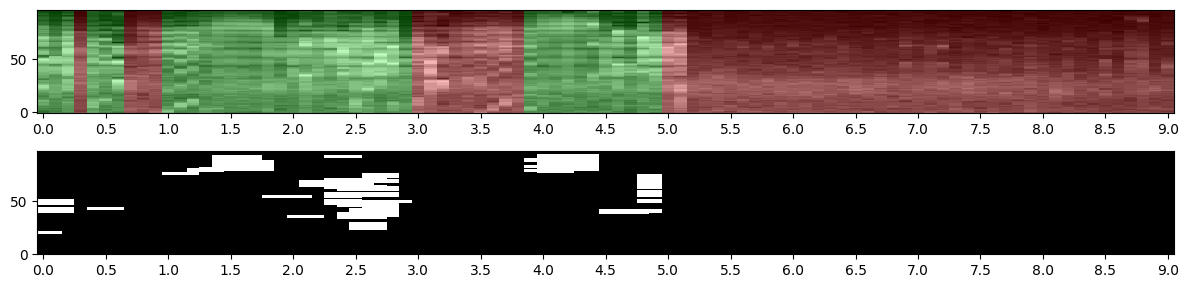

In [15]:
# plot_segmentation("thrnig1/XC25663", 34_500, 50_000)
# plot_segmentation("thrnig1/XC25663", 15_000, 22_000)
# plot_segmentation("thrnig1/XC494880", 21_000, 35_000) # pattern mince, beaucoup de bruit

# les interessants
# plot_segmentation("thrnig1/XC494880", 11_700, 21_700)
# plot_segmentation("thrnig1/XC494880", 10_000, 30_000)
plot_segmentation("barswa/XC370786", 4_500, 13_500) # semble simple mais bruit vers la fin
# plot_segmentation("barswa/XC370786", 0, None)
# plot_segmentation("combuz1/XC42427", 10_000, 20_000) # relativement simple